<a href="https://colab.research.google.com/github/5arSanti/ml-p1-eda-preprocessing/blob/main/1_Parcial_1_Practico_(Machine_Learning).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Práctico ML 1 — Preprocesamiento y EDA
## Clínica VitalPlus

**Asignatura:** Machine Learning  
**Herramienta:** R en Jupyter (Google Colab, kernel R / IRkernel)

### Índice
1. [3.1 Comprensión del negocio](#31)
2. [Setup — paquetes, repositorio y datos](#setup)
3. [3.2 Comprensión de los datos](#32)
4. [3.3 Preparación de los datos](#33)
5. [3.4 Análisis Exploratorio de Datos (EDA)](#34)
6. [3.5 Cierre](#35)

> **Colab:** Runtime → Change runtime type → **R**. Reemplazar `REPO_URL` en el setup con la URL de tu repositorio GitHub.


## 3.1 — Comprensión del negocio

Clínica VitalPlus es un centro de diagnóstico médico con sedes en varias ciudades de Colombia. La dirección quiere entender qué factores se asocian con la **duración**, el **costo** y la **satisfacción** de los exámenes, como paso previo a construir un modelo de regresión que estime el costo de un examen a partir de su duración.

**Objetivo de negocio:** Identificar patrones en los datos operativos que permitan anticipar el costo de los exámenes según su duración, mejorar la planificación de recursos y la experiencia del paciente.

**Objetivo de este análisis exploratorio:** Evaluar la calidad del dataset, limpiarlo de forma reproducible y explorar la relación duración–costo (y otras variables relevantes) para preparar el terreno del modelo de regresión.

**Criterios de éxito medibles:**
1. Dataset procesado sin valores nulos en `duracion_minutos` y `costo_examen` (variables del futuro modelo).
2. Relación duración–costo cuantificada (correlación + gráfico de dispersión) y documentada con interpretación de negocio.


## Setup — paquetes, repositorio y datos

Antes del análisis instalamos las librerías necesarias, clonamos el repositorio con el dataset y definimos funciones auxiliares que reutilizaremos en las secciones 3.2 y 3.3.


In [1]:
paquetes <- c("tidyverse", "lubridate", "skimr", "corrplot", "stringi")
for (pkg in paquetes) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    install.packages(pkg, repos = "https://cloud.r-project.org")
  }
}

library(tidyverse)
library(lubridate)
library(skimr)
library(corrplot)
library(stringi)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
corrplot 0.95 loaded



In [2]:
REPO_URL <- "https://github.com/5arSanti/ml-p1-eda-preprocessing.git"
REPO_DIR <- "ml-p1-eda-preprocessing"

if (!dir.exists(REPO_DIR)) {
  system(paste("git clone", REPO_URL))
}
setwd(REPO_DIR)

datos_crudos <- readr::read_csv(
  "data/vitalplus_pacientes.csv",
  show_col_types = FALSE
)


In [3]:
reporte_nulos <- function(df) {
  df %>%
    summarise(across(everything(), ~ sum(is.na(.x)))) %>%
    pivot_longer(everything(), names_to = "variable", values_to = "nulos") %>%
    mutate(porcentaje = round(100 * nulos / nrow(df), 2)) %>%
    arrange(desc(nulos))
}

limpiar_costo <- function(x) {
  x <- as.character(x)
  x <- str_replace_all(x, "[$\\s]", "")
  es_miles <- str_detect(x, "^\\d{1,3}(\\.\\d{3})+$")
  x[which(es_miles)] <- str_replace_all(x[which(es_miles)], "\\.", "")
  as.numeric(x)
}

winsorizar_iqr <- function(x, mult = 1.5) {
  q <- quantile(x, probs = c(0.25, 0.75), na.rm = TRUE)
  iqr_val <- q[2] - q[1]
  lim_inf <- q[1] - mult * iqr_val
  lim_sup <- q[2] + mult * iqr_val
  recortados <- sum(x < lim_inf | x > lim_sup, na.rm = TRUE)
  list(
    valor = pmin(pmax(x, lim_inf), lim_sup),
    lim_inf = lim_inf,
    lim_sup = lim_sup,
    recortados = recortados
  )
}

normalizar_texto <- function(x) {
  x <- str_trim(as.character(x))
  x <- stri_trans_general(x, "Latin-ASCII")
  str_to_lower(x)
}


## 3.2 — Comprensión de los datos

En esta sección describimos la estructura del dataset y elaboramos un reporte de calidad por columna: valores nulos, filas duplicadas, valores fuera de rango u outliers, e inconsistencias en categorías y formatos. Todo el análisis se realiza sobre `datos_crudos` sin modificar los datos.


In [36]:
cat("Registros:", nrow(datos_crudos), "\n")
cat("Variables:", ncol(datos_crudos), "\n")
cat("Nombres:", paste(names(datos_crudos), collapse = ", "), "\n\n")
glimpse(datos_crudos)
skim(datos_crudos)


Registros: 576 
Variables: 11 
Nombres: id_paciente, edad, sede, tipo_examen, fecha_cita, dias_espera_cita, duracion_minutos, costo_examen, canal_remision, calificacion_satisfaccion, reingreso_30dias 

Rows: 576
Columns: 11
$ id_paciente               <dbl> 5388, 5455, 5533, 5281, 5324, 5359, 5049, 55…
$ edad                      <dbl> 37, 43, 49, 46, 40, 49, 34, 35, 34, 26, 37, …
$ sede                      <chr> "Bogota", "Cali", "Bogota", NA, "cali", "Bog…
$ tipo_examen               <chr> "Radiografía", "RMN", "LABORATORIO", "ecogra…
$ fecha_cita                <chr> "2023-10-23", "28-Apr-2024", "12-31-2025", "…
$ dias_espera_cita          <dbl> 14, 6, 6, 2, 10, 5, 8, 5, 5, 6, 90, 3, 4, 12…
$ duracion_minutos          <dbl> 9, 77, 9, 28, 27, 35, 19, 35, 9, 12, 10, 21,…
$ costo_examen              <chr> "98000.0", "311000.0", "51000.0", NA, "14400…
$ canal_remision            <chr> "EPS", "particular", "Particular", "REMITIDO…
$ calificacion_satisfaccion <dbl> 3, 5, 2, 4, NA, 3, 5, 

,skim_type,skim_variable,n_missing,complete_rate,character.min,character.max,character.empty,character.n_unique,character.whitespace,numeric.mean,numeric.sd,numeric.p0,numeric.p25,numeric.p50,numeric.p75,numeric.p100,numeric.hist
,<chr>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,character,sede,8,0.9861111,4,11,0,13,0,NA,NA,NA,NA,NA,NA,NA,NA
2,character,tipo_examen,12,0.9791667,2,11,0,20,0,NA,NA,NA,NA,NA,NA,NA,NA
3,character,fecha_cita,0,1.0000000,10,11,0,560,0,NA,NA,NA,NA,NA,NA,NA,NA
4,character,costo_examen,34,0.9409722,4,9,0,225,0,NA,NA,NA,NA,NA,NA,NA,NA
5,character,canal_remision,16,0.9722222,3,18,0,12,0,NA,NA,NA,NA,NA,NA,NA,NA
6,numeric,id_paciente,0,1.0000000,NA,NA,NA,NA,NA,5278.5815972,162.2081334,5001,5137.75,5277.5,5418.25,5560,▇▇▇▇▇
7,numeric,edad,16,0.9722222,NA,NA,NA,NA,NA,42.6071429,17.1350299,-20,32.00,43.0,53.00,180,▁▇▁▁▁
8,numeric,dias_espera_cita,0,1.0000000,NA,NA,NA,NA,NA,6.3888889,6.2530534,-1,4.00,6.0,8.00,90,▇▁▁▁▁
9,numeric,duracion_minutos,22,0.9618056,NA,NA,NA,NA,NA,24.6335740,28.3838522,0,12.00,19.0,30.00,400,▇▁▁▁▁


El dataset contiene **576 registros** y **11 variables**. Al leer el CSV, `costo_examen` aparece como texto (character) porque algunos valores incluyen símbolos de moneda y separadores de miles. `fecha_cita` también es texto con formatos de fecha mezclados. Las variables numéricas (`edad`, `duracion_minutos`, `calificacion_satisfaccion`) tienen valores nulos parciales que debemos cuantificar.


In [37]:
tabla_nulos <- reporte_nulos(datos_crudos)
print(tabla_nulos)


# A tibble: 11 × 3
   variable                  nulos porcentaje
   <chr>                     <int>      <dbl>
 1 costo_examen                 34       5.9 
 2 duracion_minutos             22       3.82
 3 edad                         16       2.78
 4 canal_remision               16       2.78
 5 calificacion_satisfaccion    16       2.78
 6 tipo_examen                  12       2.08
 7 sede                          8       1.39
 8 id_paciente                   0       0   
 9 fecha_cita                    0       0   
10 dias_espera_cita              0       0   
11 reingreso_30dias              0       0   


Las columnas con más valores faltantes son `costo_examen` (~6%) y `duracion_minutos` (~4%). También hay nulos en `edad`, `canal_remision` y `calificacion_satisfaccion` (~3% cada una). Las variables `id_paciente`, `fecha_cita`, `dias_espera_cita` y `reingreso_30dias` no tienen nulos. Estos vacíos deben tratarse en la fase 3.3, con especial atención a duración y costo por ser las variables del futuro modelo.


In [38]:
duplicados_exactos <- sum(duplicated(datos_crudos))
duplicados_id <- sum(duplicated(datos_crudos$id_paciente))

cat("Filas duplicadas (exactas):", duplicados_exactos, "\n")
cat("id_paciente repetidos:", duplicados_id, "\n")

datos_crudos %>%
  count(id_paciente) %>%
  filter(n > 1) %>%
  head(10)


Filas duplicadas (exactas): 16 
id_paciente repetidos: 16 


id_paciente,n
<dbl>,<int>
5009,2
5026,2
5046,2
5050,2
5075,2
5096,2
5122,2
5165,2
5225,2


Se detectan **16 filas duplicadas** y **16 identificadores de paciente repetidos**. Esto sugiere registros duplicados por error de captura, no pacientes distintos con el mismo ID. En el preprocesamiento eliminaremos duplicados conservando la primera aparición de cada `id_paciente`.


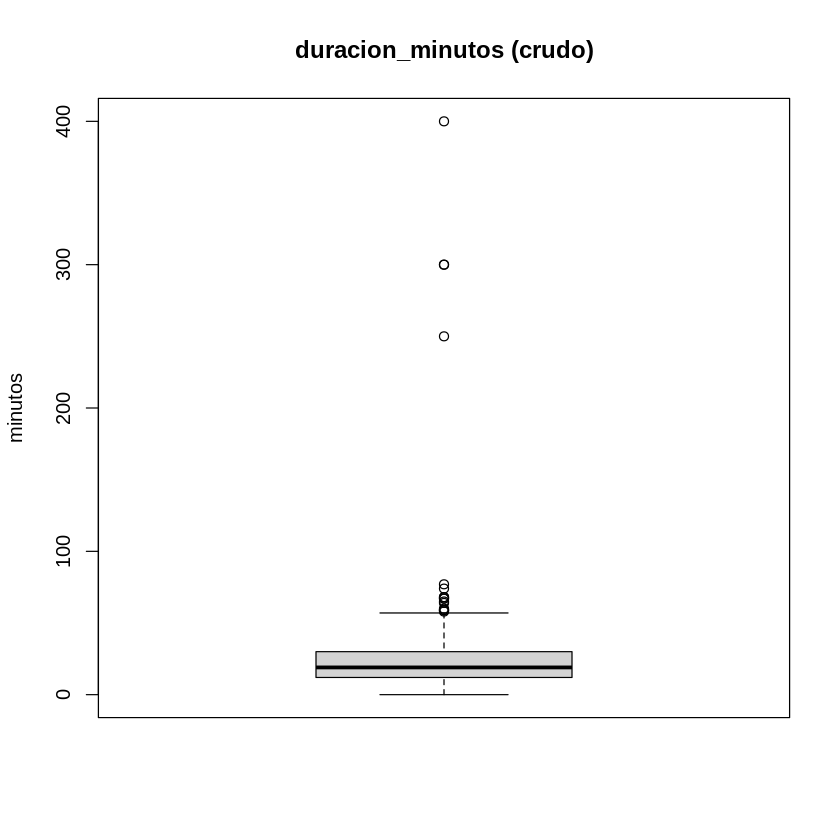

Calificación fuera de 1-5: 5 
Edad fuera de 0-120: 4 
Max duracion_minutos: 400 
Max costo_examen: 3200000 


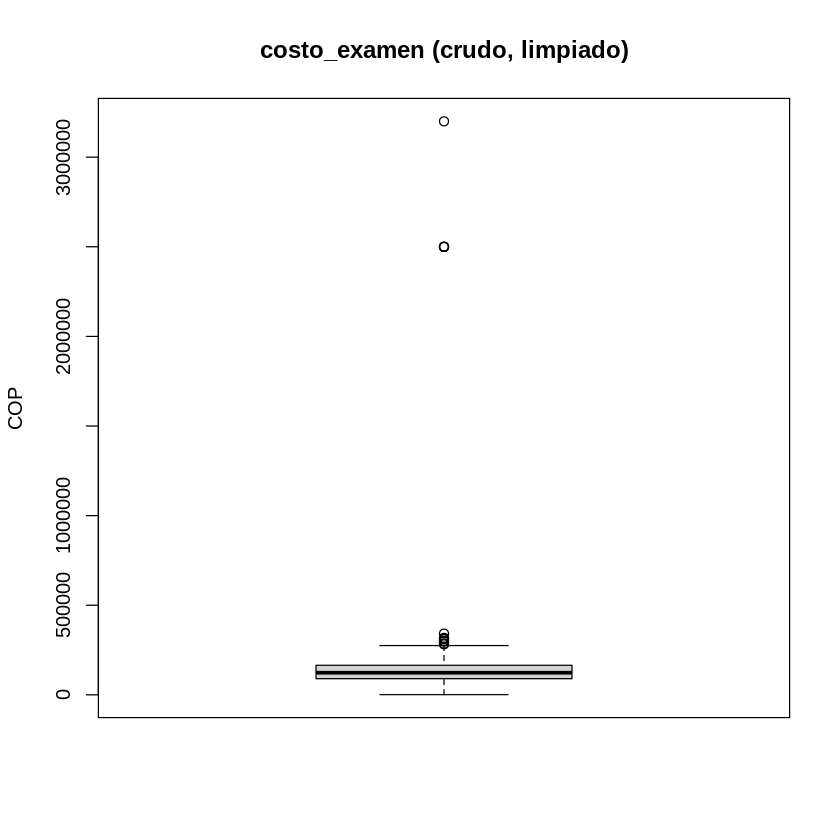

In [39]:
costo_num_crudo <- limpiar_costo(datos_crudos$costo_examen)

boxplot(
  datos_crudos$duracion_minutos,
  main = "duracion_minutos (crudo)",
  ylab = "minutos"
)
boxplot(
  costo_num_crudo,
  main = "costo_examen (crudo, limpiado)",
  ylab = "COP"
)

fuera_rango_cal <- sum(
  datos_crudos$calificacion_satisfaccion < 1 |
    datos_crudos$calificacion_satisfaccion > 5,
  na.rm = TRUE
)
fuera_rango_edad <- sum(
  datos_crudos$edad < 0 | datos_crudos$edad > 120,
  na.rm = TRUE
)

cat("Calificación fuera de 1-5:", fuera_rango_cal, "\n")
cat("Edad fuera de 0-120:", fuera_rango_edad, "\n")
cat("Max duracion_minutos:", max(datos_crudos$duracion_minutos, na.rm = TRUE), "\n")
cat("Max costo_examen:", max(costo_num_crudo, na.rm = TRUE), "\n")


Los boxplots revelan valores extremos en **duración** (hasta 400 minutos) y **costo** (valores muy superiores al rango típico). Además hay **5 calificaciones fuera del rango 1–5** y **4 edades fuera de 0–120 años**, que son errores de captura. En 3.3 corregiremos rangos inválidos y aplicaremos winsorización IQR a duración y costo para reducir el efecto de outliers en la futura regresión, sin eliminar filas.


In [40]:
cat("--- sede (valores únicos) ---\n")
datos_crudos %>% count(sede, sort = TRUE) %>% print(n = 20)

cat("\n--- tipo_examen (valores únicos) ---\n")
datos_crudos %>% count(tipo_examen, sort = TRUE) %>% print(n = 20)

cat("\n--- canal_remision (valores únicos) ---\n")
datos_crudos %>% count(canal_remision, sort = TRUE) %>% print(n = 20)


--- sede (valores únicos) ---
# A tibble: 14 × 2
   sede            n
   <chr>       <int>
 1 BOGOTA         69
 2 bogota         64
 3 Bogota         58
 4 Bogotá         57
 5 Medellín       56
 6 MEDELLIN       55
 7 cali           42
 8 medellin       42
 9 BUCARAMANGA    31
10 Cali           30
11 Bucaramanga    22
12 CALI           21
13 bucaramanga    21
14 NA              8

--- tipo_examen (valores únicos) ---
# A tibble: 21 × 2
   tipo_examen     n
   <chr>       <int>
 1 Radiografía    45
 2 Ecografía      42
 3 RADIOGRAFIA    41
 4 ECOGRAFIA      40
 5 Eco            39
 6 ecografia      39
 7 Laboratorio    37
 8 laboratorio    34
 9 radiografia    33
10 Lab            32
11 Rx             32
12 LABORATORIO    26
13 tomografia     20
14 TAC            19
15 RESONANCIA     18
16 TOMOGRAFIA     15
17 Tomografía     14
18 RMN            13
19 Resonancia     13
20 resonancia     12
# ℹ 1 more row

--- canal_remision (valores únicos) ---
# A tibble: 13 × 2
   canal_remision    

Las tres variables categóricas muestran **inconsistencias de formato**: mayúsculas/minúsculas (`BOGOTA` vs `Bogotá`), acentos (`Bogota` vs `Bogotá`), abreviaturas (`Lab` vs `Laboratorio`, `Eco` vs `Ecografía`, `Rx` vs `Radiografía`) y variantes de canal (`EPS` vs `E.P.S.`, `Prepagada` vs `Medicina prepagada`). En 3.3 aplicaremos un diccionario de mapeo explícito hacia categorías canónicas.


In [41]:
cat("Muestra de formatos en fecha_cita:\n")
datos_crudos %>%
  distinct(fecha_cita) %>%
  slice_head(n = 15)

costo_texto <- as.character(datos_crudos$costo_examen)
formato_moneda <- sum(grepl("[$]", costo_texto), na.rm = TRUE)
cat("\nRegistros de costo con símbolo $:", formato_moneda, "\n")

cat("\nMuestra de costos con formato no estándar:\n")
datos_crudos %>%
  filter(grepl("[$]", as.character(costo_examen))) %>%
  select(id_paciente, costo_examen) %>%
  head(10)


Muestra de formatos en fecha_cita:


fecha_cita
<chr>
2023-10-23
28-Apr-2024
12-31-2025
2024-03-24
07/10/2025
27-Aug-2025
2025-10-23
14-Jan-2023
08/07/2024



Registros de costo con símbolo $: 20 

Muestra de costos con formato no estándar:


id_paciente,costo_examen
<dbl>,<chr>
5273,$ 85.000
5339,$ 98.000
5318,$ 153.000
5416,$ 92.000
5067,$ 78.000
5016,$ 167.000
5343,$ 79.000
5032,$ 131.000
5362,$ 201.000


### Resumen del reporte de calidad

| Problema | Columnas afectadas | Magnitud |
|----------|---------------------|----------|
| Valores nulos | costo, duración, edad, sede, tipo_examen, canal, calificación | 1–6% por columna |
| Duplicados | id_paciente | 16 registros |
| Outliers | duracion_minutos, costo_examen | Valores extremos visibles en boxplots |
| Fuera de rango | calificacion_satisfaccion, edad | 5 y 4 registros respectivamente |
| Categorías inconsistentes | sede, tipo_examen, canal_remision | Múltiples variantes por categoría |
| Formatos mixtos | fecha_cita, costo_examen | Varios formatos de fecha; costos con `$` y puntos de miles |

Este diagnóstico guía el pipeline de limpieza en la sección 3.3.


## 3.3 — Preparación de los datos

A partir de los problemas detectados en 3.2, aplicamos un pipeline de limpieza secuencial. Cada decisión incluye la técnica elegida y la alternativa descartada. El resultado final se guarda en `datos_limpios` y se exporta como CSV.


### 3.3.1 — Duplicados

**Problema:** 16 registros con `id_paciente` repetido.  
**Técnica:** Eliminar duplicados por `id_paciente`, conservando la primera aparición (`distinct(.keep_all = TRUE)`).  
**Alternativa descartada:** Mantener duplicados o promediar valores — distorsionaría conteos y relaciones en el EDA.


In [42]:
datos_limpios <- datos_crudos %>%
  distinct(id_paciente, .keep_all = TRUE)

cat("Filas antes:", nrow(datos_crudos), "→ después:", nrow(datos_limpios), "\n")


Filas antes: 576 → después: 560 


### 3.3.2 — Categorías inconsistentes

**Problema:** Variantes de sede, tipo de examen y canal de remisión (mayúsculas, acentos, abreviaturas).  
**Técnica:** Normalizar texto (trim, minúsculas, sin acentos) y mapear con diccionario explícito hacia categorías canónicas. Valores nulos o no reconocidos → `"Desconocido"`.  
**Alternativa descartada:** Imputar con la moda — sesgaría hacia Bogotá/EPS que ya son las categorías más frecuentes.


In [43]:
map_sede <- c(
  "bogota" = "Bogotá", "cali" = "Cali",
  "medellin" = "Medellín", "bucaramanga" = "Bucaramanga"
)
map_tipo <- c(
  "laboratorio" = "Laboratorio", "lab" = "Laboratorio",
  "ecografia" = "Ecografía", "eco" = "Ecografía",
  "radiografia" = "Radiografía", "rx" = "Radiografía",
  "resonancia" = "Resonancia", "rmn" = "Resonancia",
  "tomografia" = "Tomografía", "tac" = "Tomografía"
)
map_canal <- c(
  "eps" = "EPS", "e.p.s." = "EPS",
  "particular" = "Particular",
  "remitido" = "Remitido",
  "prepagada" = "Medicina prepagada",
  "medicina prepagada" = "Medicina prepagada"
)

datos_limpios <- datos_limpios %>%
  mutate(
    sede_norm = normalizar_texto(sede),
    tipo_norm = normalizar_texto(tipo_examen),
    canal_norm = normalizar_texto(canal_remision),
    sede = map_sede[sede_norm],
    tipo_examen = map_tipo[tipo_norm],
    canal_remision = map_canal[canal_norm]
  ) %>%
  mutate(
    sede = if_else(is.na(sede), "Desconocido", sede),
    tipo_examen = if_else(is.na(tipo_examen), "Desconocido", tipo_examen),
    canal_remision = if_else(is.na(canal_remision), "Desconocido", canal_remision)
  ) %>%
  select(-sede_norm, -tipo_norm, -canal_norm)

datos_limpios %>% count(sede, sort = TRUE)
datos_limpios %>% count(tipo_examen, sort = TRUE)
datos_limpios %>% count(canal_remision, sort = TRUE)


sede,n
<chr>,<int>
Bogotá,241
Medellín,149
Cali,91
Bucaramanga,71
Desconocido,8


tipo_examen,n
<chr>,<int>
Ecografía,154
Radiografía,149
Laboratorio,125
Tomografía,65
Resonancia,56
Desconocido,11


canal_remision,n
<chr>,<int>
EPS,222
Particular,117
Remitido,105
Medicina prepagada,100
Desconocido,16


### 3.3.3 — Formatos de fecha inconsistentes

**Problema:** `fecha_cita` mezcla formatos (`YYYY-MM-DD`, `DD-Mon-YYYY`, `DD/MM/YYYY`, etc.).  
**Técnica:** `parse_date_time()` con múltiples órdenes (`ymd`, `dmy`, `mdy`, `bmdy`, `bdmy`).  
**Alternativa descartada:** `as.Date()` con un solo formato — falla con formatos heterogéneos.


In [44]:
datos_limpios <- datos_limpios %>%
  mutate(
    fecha_cita = parse_date_time(
      fecha_cita,
      orders = c("ymd", "dmy", "mdy", "bmdy", "bdmy"),
      quiet = TRUE
    )
  )

fechas_na <- sum(is.na(datos_limpios$fecha_cita))
cat("Fechas no parseadas:", fechas_na, "\n")


Fechas no parseadas: 0 


### 3.3.4 — costo_examen almacenado como texto

**Problema:** Valores con `$`, espacios y punto como separador de miles (ej. `$ 85.000`).  
**Técnica:** Función `limpiar_costo()` — elimina `$` y espacios, quita puntos de miles, convierte a numérico.  
**Alternativa descartada:** Eliminar filas no parseables — perderíamos ~54 registros con información útil.


In [45]:
datos_limpios <- datos_limpios %>%
  mutate(costo_examen = limpiar_costo(costo_examen))

cat("Nulos en costo tras limpieza:", sum(is.na(datos_limpios$costo_examen)), "\n")
summary(datos_limpios$costo_examen)


Nulos en costo tras limpieza: 33 


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.     NAs 
   1000   90000  124000  155059  165000 3200000      33 

### 3.3.5 — Valores fuera de rango

**Problema:** Calificaciones fuera de 1–5 y edades fuera de 0–120.  
**Técnica:** Reemplazar valores inválidos por `NA` para imputar después.  
**Alternativa descartada:** Conservar valores erróneos — distorsionarían estadísticas y correlaciones.


In [46]:
datos_limpios <- datos_limpios %>%
  mutate(
    calificacion_satisfaccion = if_else(
      calificacion_satisfaccion < 1 | calificacion_satisfaccion > 5,
      NA_real_, calificacion_satisfaccion
    ),
    edad = if_else(edad < 0 | edad > 120, NA_real_, edad),
    dias_espera_cita = if_else(dias_espera_cita < 0, NA_real_, dias_espera_cita),
    duracion_minutos = if_else(duracion_minutos <= 0, NA_real_, duracion_minutos)
  )

### 3.3.6 — Valores nulos

**Problema:** Nulos restantes en edad, calificación, sede, tipo_examen, canal, duración y costo.  
**Técnicas:**
- `edad` y `calificacion_satisfaccion`: mediana global (robusta ante outliers).
- `sede`, `tipo_examen`, `canal_remision`: categoría `"Desconocido"`.
- `duracion_minutos` y `costo_examen`: mediana **por `tipo_examen`** (un laboratorio no debe imputarse con la duración de una resonancia).

**Alternativa descartada para duración/costo:** mediana global — ignoraría que distintos tipos de examen tienen duraciones y costos muy diferentes.


In [47]:
mediana_edad <- median(datos_limpios$edad, na.rm = TRUE)
mediana_cal <- median(datos_limpios$calificacion_satisfaccion, na.rm = TRUE)
mediana_espera <- median(datos_limpios$dias_espera_cita, na.rm = TRUE)

medias_por_tipo <- datos_limpios %>%
  group_by(tipo_examen) %>%
  summarise(
    med_dur = median(duracion_minutos, na.rm = TRUE),
    med_costo = median(costo_examen, na.rm = TRUE),
    .groups = "drop"
  )

datos_limpios <- datos_limpios %>%
  left_join(medias_por_tipo, by = "tipo_examen") %>%
  mutate(
    edad = if_else(is.na(edad), mediana_edad, edad),
    calificacion_satisfaccion = if_else(
      is.na(calificacion_satisfaccion), mediana_cal, calificacion_satisfaccion
    ),
    dias_espera_cita = if_else(is.na(dias_espera_cita), mediana_espera, dias_espera_cita),
    sede = if_else(is.na(sede), "Desconocido", sede),
    tipo_examen = if_else(is.na(tipo_examen), "Desconocido", tipo_examen),
    canal_remision = if_else(is.na(canal_remision), "Desconocido", canal_remision),
    duracion_minutos = if_else(is.na(duracion_minutos), med_dur, duracion_minutos),
    costo_examen = if_else(is.na(costo_examen), med_costo, costo_examen)
  ) %>%
  select(-med_dur, -med_costo)

print(reporte_nulos(datos_limpios))


# A tibble: 11 × 3
   variable                  nulos porcentaje
   <chr>                     <int>      <dbl>
 1 id_paciente                   0          0
 2 edad                          0          0
 3 sede                          0          0
 4 tipo_examen                   0          0
 5 fecha_cita                    0          0
 6 dias_espera_cita              0          0
 7 duracion_minutos              0          0
 8 costo_examen                  0          0
 9 canal_remision                0          0
10 calificacion_satisfaccion     0          0
11 reingreso_30dias              0          0


### 3.3.7 — Outliers en duracion_minutos y costo_examen

**Problema:** Valores extremos en duración (hasta 400 min) y costo que pueden distorsionar una regresión lineal.  
**Técnica:** Winsorización IQR (1.5×): recortar valores por debajo de Q1−1.5·IQR y por encima de Q3+1.5·IQR al límite correspondiente.  
**Alternativas descartadas:**
- *Eliminar filas outlier:* reduce el tamaño muestral (~560 filas).
- *Conservar sin tratar:* apalanca coeficientes de la regresión futura.
- *Log-transform aquí:* cambia la interpretabilidad; se evaluará en 3.5 para el modelado.


In [48]:
antes_dur <- datos_limpios$duracion_minutos
antes_costo <- datos_limpios$costo_examen

datos_limpios <- datos_limpios %>%
  group_by(tipo_examen) %>%
  mutate(
    duracion_minutos = winsorizar_iqr(duracion_minutos)$valor,
    costo_examen = winsorizar_iqr(costo_examen)$valor
  ) %>%
  ungroup()

cat("Duración — recortados:", sum(antes_dur != datos_limpios$duracion_minutos), "\n")
cat("Costo — recortados:", sum(antes_costo != datos_limpios$costo_examen), "\n")

datos_limpios %>%
  group_by(tipo_examen) %>%
  summarise(
    dur_min = min(duracion_minutos),
    dur_max = max(duracion_minutos),
    costo_max = max(costo_examen),
    .groups = "drop"
  )

Duración — recortados: 12 
Costo — recortados: 15 


tipo_examen,dur_min,dur_max,costo_max
<chr>,<dbl>,<dbl>,<dbl>
Desconocido,9.0,30.000,243000
Ecografía,7.5,43.500,227250
Laboratorio,3.5,15.500,146000
Radiografía,5.5,25.500,172000
Resonancia,24.0,83.125,345500
Tomografía,21.0,50.000,258000


In [49]:
readr::write_csv(datos_limpios, "data/vitalplus_pacientes_procesado.csv")
cat("Exportado: data/vitalplus_pacientes_procesado.csv\n")
cat("Filas finales:", nrow(datos_limpios), "\n")


Exportado: data/vitalplus_pacientes_procesado.csv
Filas finales: 560 


### Resumen del preprocesamiento

| Aspecto | Antes (crudo) | Después (limpio) |
|---------|---------------|------------------|
| Filas | 576 | 560 (16 duplicados eliminados) |
| Nulos en duración/costo | Sí | No |
| Categorías | Inconsistentes | 5 sedes, 6 tipos, 5 canales canónicos |
| Outliers duración/costo | Extremos visibles | Winsorizados (IQR 1.5×) |

El dataset procesado está listo para el EDA en 3.4 y como base para el futuro modelo de regresión.


## 3.4 — Análisis Exploratorio de Datos (EDA)

Exploramos la distribución de variables individuales (univariado), relaciones entre variables (bivariado) y la matriz de correlación. El foco principal es la relación **duración–costo**, anticipo del futuro modelo de regresión.


### 3.4.1 — Distribución de duracion_minutos

La duración del examen es la variable independiente del futuro modelo. Analizamos su distribución para entender si los exámenes son mayormente cortos o si hay una cola larga hacia procedimientos más extensos.


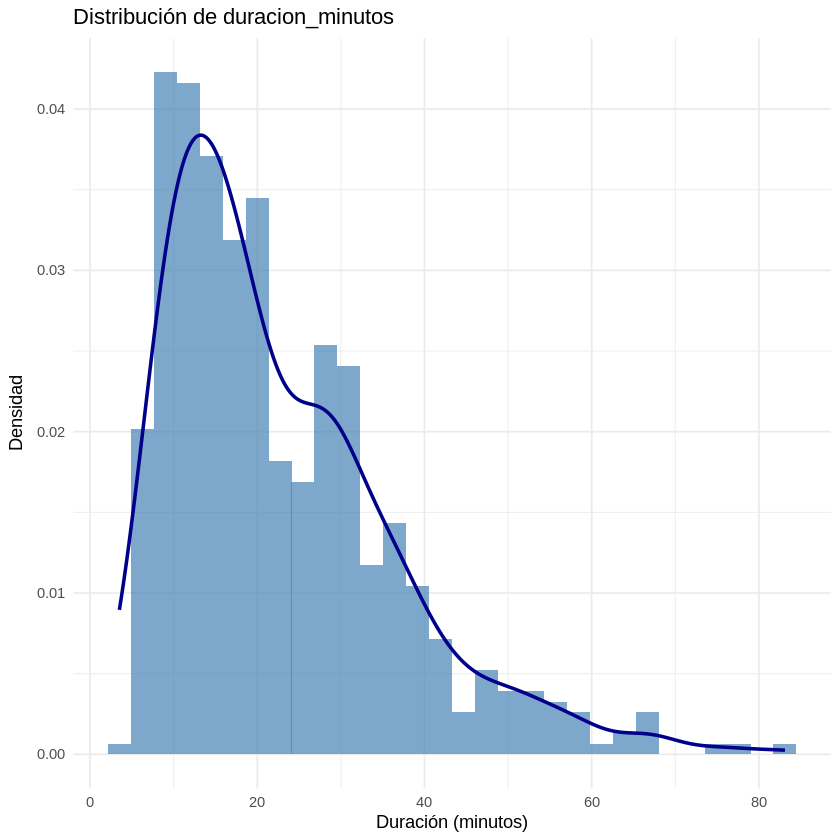

In [50]:
ggplot(datos_limpios, aes(x = duracion_minutos)) +
  geom_histogram(aes(y = after_stat(density)), bins = 30, fill = "steelblue", alpha = 0.7) +
  geom_density(color = "darkblue", linewidth = 1) +
  labs(
    title = "Distribución de duracion_minutos",
    x = "Duración (minutos)", y = "Densidad"
  ) +
  theme_minimal()


La distribución es **asimétrica hacia la derecha**: la mayoría de exámenes dura menos de 30 minutos (laboratorios y radiografías), pero existe una cola de procedimientos más largos (resonancias, tomografías). Esto implica que la relación con el costo podría no ser uniforme en todos los tipos de examen.


### 3.4.1 — Distribución de costo_examen

El costo del examen es la variable que el futuro modelo intentará predecir. Su distribución nos indica si los precios son homogéneos o si hay un grupo de exámenes de alto costo.


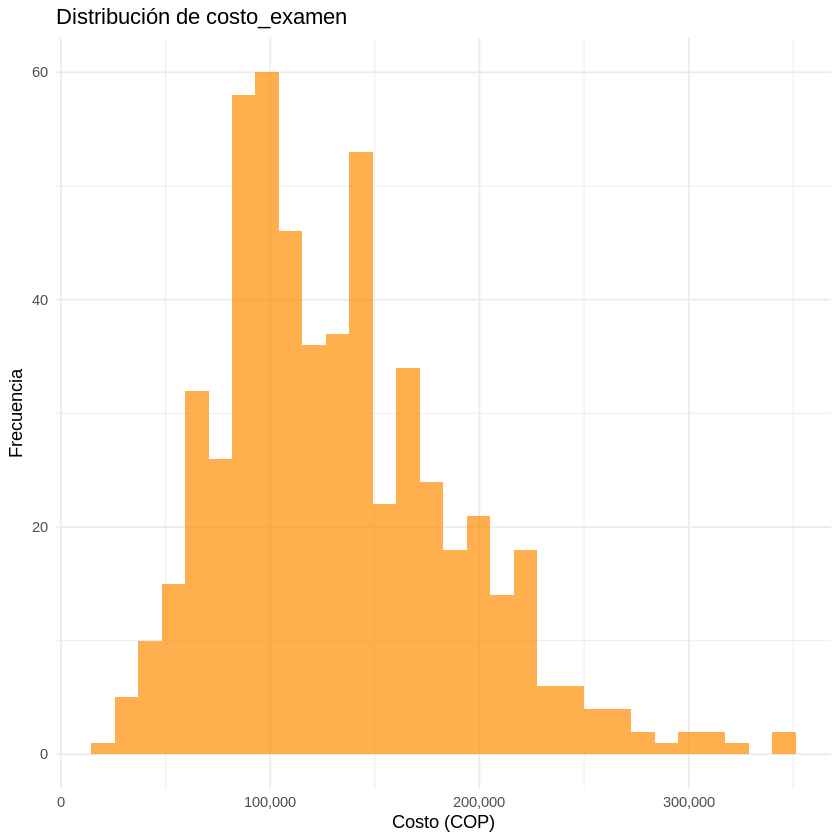

In [51]:
ggplot(datos_limpios, aes(x = costo_examen)) +
  geom_histogram(bins = 30, fill = "darkorange", alpha = 0.7) +
  scale_x_continuous(labels = scales::comma) +
  labs(
    title = "Distribución de costo_examen",
    x = "Costo (COP)", y = "Frecuencia"
  ) +
  theme_minimal()


El costo también presenta **asimetría positiva**: la mayoría de exámenes cuesta entre 80.000 y 200.000 COP, con un grupo minoritario de procedimientos de alto costo. Esta asimetría sugiere que el equipo de modelado podría evaluar una transformación logarítmica del costo en la siguiente entrega.


### 3.4.1 — Distribución de tipo_examen

Analizamos qué tipos de examen concentran la demanda de la clínica, lo que orienta la planificación de capacidad operativa.


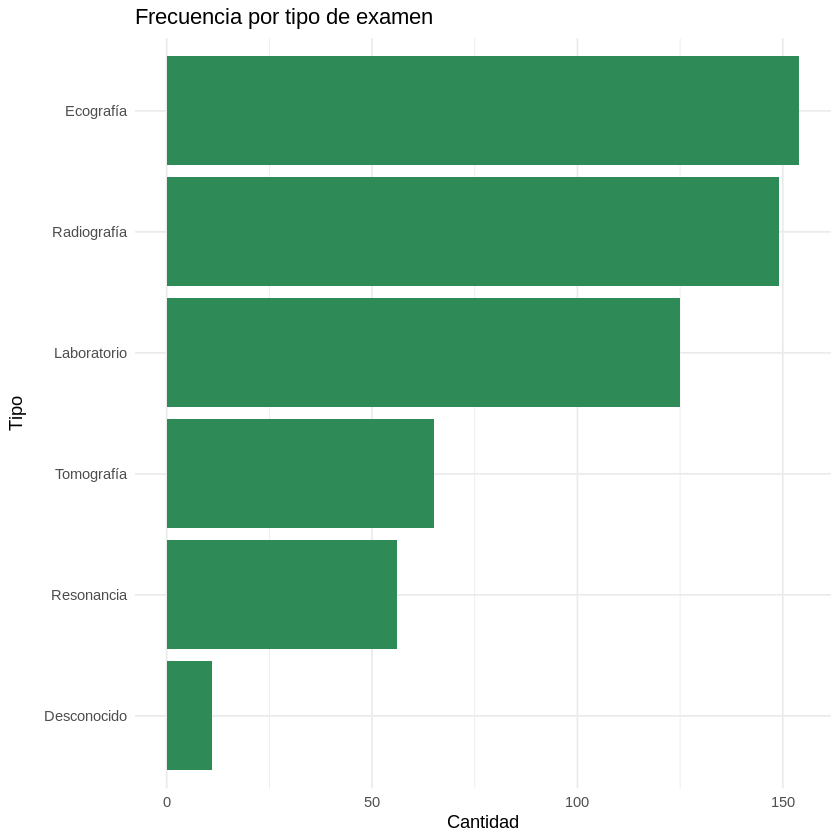

In [52]:
datos_limpios %>%
  count(tipo_examen) %>%
  ggplot(aes(x = reorder(tipo_examen, n), y = n)) +
  geom_col(fill = "seagreen") +
  coord_flip() +
  labs(title = "Frecuencia por tipo de examen", x = "Tipo", y = "Cantidad") +
  theme_minimal()


Las **ecografías** (154) y **radiografías** (149) concentran la mayor parte de la
demanda, seguidas por los laboratorios (125). Los procedimientos más largos y
costosos: tomografías (65) y resonancias (56), representan una fracción menor del
volumen.

### 3.4.1 — Distribución de canal_remision

El canal por el que llega el paciente influye en la operación y en los acuerdos de facturación de la clínica.


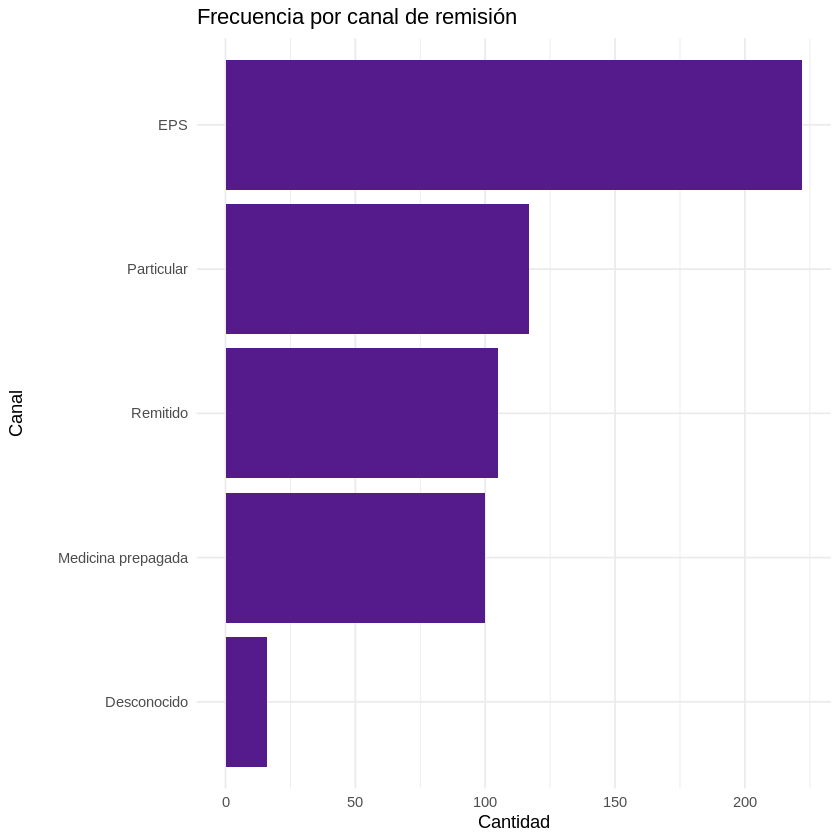

In [53]:
datos_limpios %>%
  count(canal_remision) %>%
  ggplot(aes(x = reorder(canal_remision, n), y = n)) +
  geom_col(fill = "purple4") +
  coord_flip() +
  labs(title = "Frecuencia por canal de remisión", x = "Canal", y = "Cantidad") +
  theme_minimal()


El canal **EPS** es el principal origen de pacientes, seguido por **particular** y **remitido**. La medicina prepagada representa una porción menor pero relevante del volumen.


### 3.4.2 — Relación duración vs costo (anticipo de regresión)

Este gráfico de dispersión es el análisis central: muestra si a mayor duración del examen corresponde un mayor costo, que es la hipótesis del futuro modelo de regresión lineal.


Correlación Pearson (lineal): 0.849 
Correlación Spearman (monótona): 0.837 


`geom_smooth()` using formula = 'y ~ x'


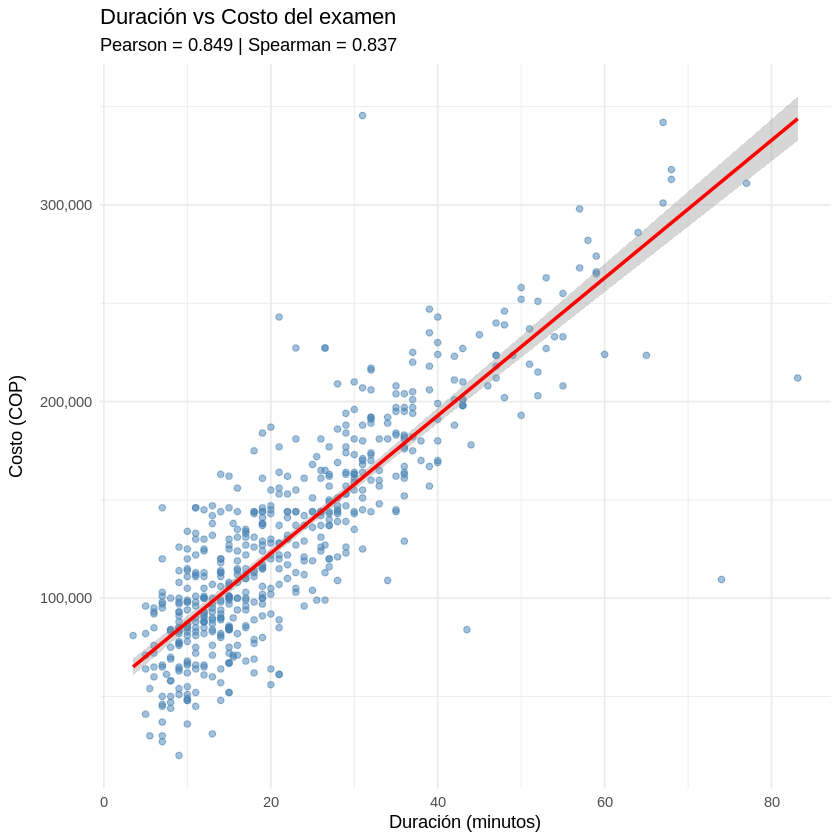

In [54]:
cor_dur_costo <- cor(datos_limpios$duracion_minutos, datos_limpios$costo_examen)
cor_spearman <- cor(datos_limpios$duracion_minutos, datos_limpios$costo_examen,
                    method = "spearman")

cat("Correlación Pearson (lineal):", round(cor_dur_costo, 3), "\n")
cat("Correlación Spearman (monótona):", round(cor_spearman, 3), "\n")

ggplot(datos_limpios, aes(x = duracion_minutos, y = costo_examen)) +
  geom_point(alpha = 0.5, color = "steelblue") +
  geom_smooth(method = "lm", se = TRUE, color = "red") +
  scale_y_continuous(labels = scales::comma) +
  labs(
    title = "Duración vs Costo del examen",
    subtitle = paste0("Pearson = ", round(cor_dur_costo, 3),
                      " | Spearman = ", round(cor_spearman, 3)),
    x = "Duración (minutos)", y = "Costo (COP)"
  ) +
  theme_minimal()

Se observa una **relación positiva** entre duración y costo: los exámenes más largos tienden a ser más costosos. Sin embargo, hay **dispersión considerable** alrededor de la línea de tendencia, lo que indica que la duración sola no explica todo el costo (el tipo de examen y el canal también influyen).


### 3.4.2 — Satisfacción vs días de espera

Exploramos si los pacientes que esperan más días para su cita tienden a calificar peor el servicio, un indicador clave de calidad percibida.


`geom_smooth()` using formula = 'y ~ x'


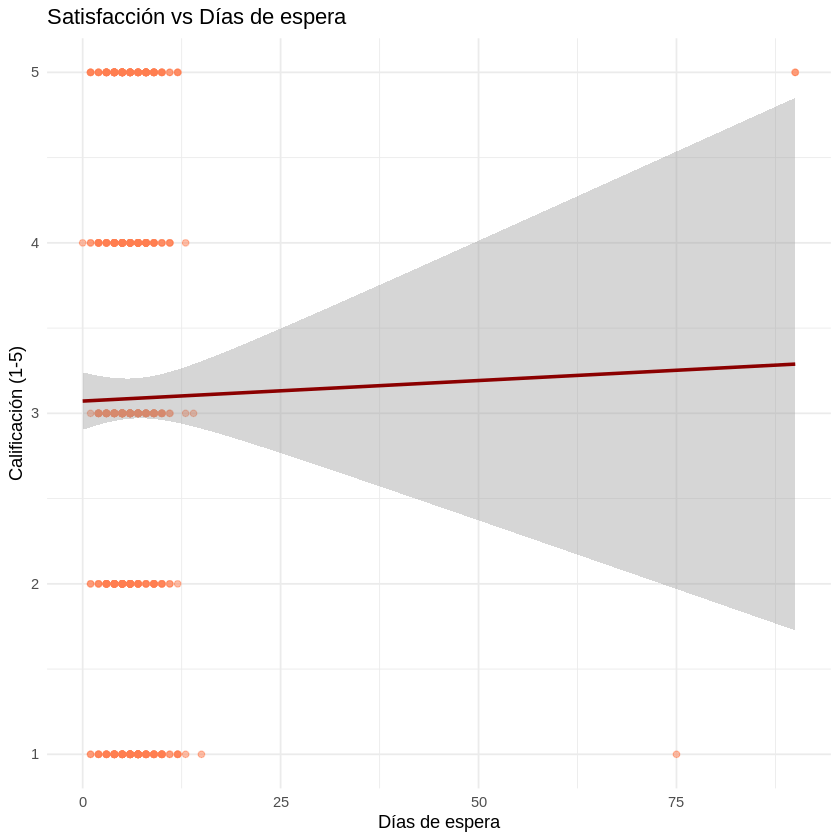

In [55]:
ggplot(datos_limpios, aes(x = dias_espera_cita, y = calificacion_satisfaccion)) +
  geom_point(alpha = 0.5, color = "coral") +
  geom_smooth(method = "lm", se = TRUE, color = "darkred") +
  labs(
    title = "Satisfacción vs Días de espera",
    x = "Días de espera", y = "Calificación (1-5)"
  ) +
  theme_minimal()


La tendencia sugiere que **mayor tiempo de espera se asocia con menor satisfacción**. Aunque la relación es moderada, reducir los días de espera podría mejorar la experiencia del paciente sin necesidad de modificar precios.


Correlación espera-satisfacción: 0.011 


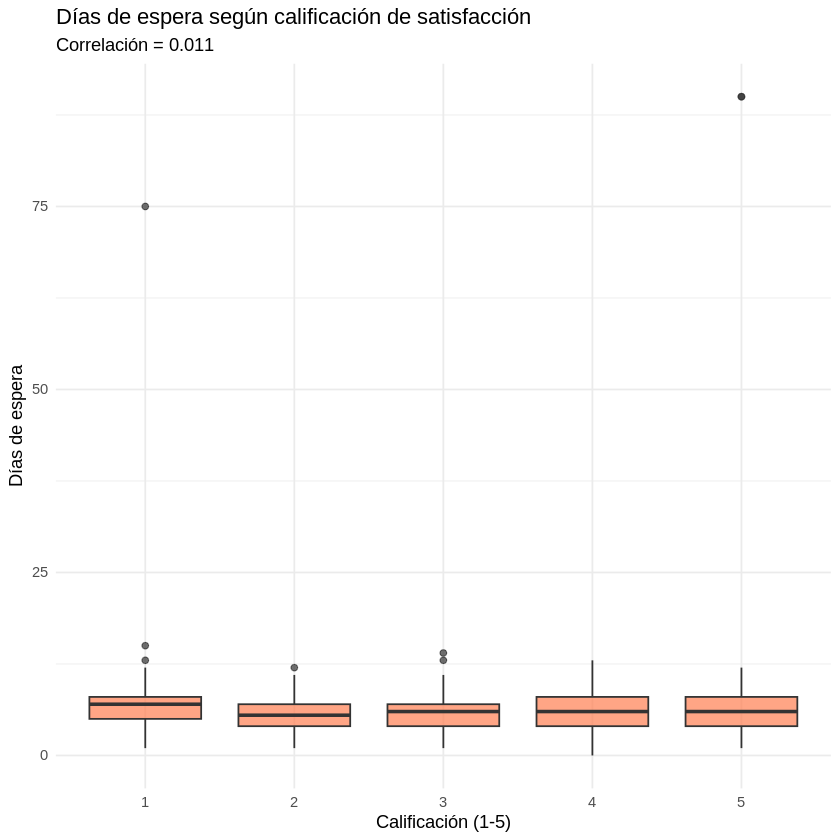

In [56]:
cor_espera <- cor(datos_limpios$dias_espera_cita,
                  datos_limpios$calificacion_satisfaccion)
cat("Correlación espera-satisfacción:", round(cor_espera, 3), "\n")

datos_limpios %>%
  mutate(calificacion = factor(calificacion_satisfaccion)) %>%
  ggplot(aes(x = calificacion, y = dias_espera_cita)) +
  geom_boxplot(fill = "coral", alpha = 0.7) +
  labs(
    title = "Días de espera según calificación de satisfacción",
    subtitle = paste0("Correlación = ", round(cor_espera, 3)),
    x = "Calificación (1-5)", y = "Días de espera"
  ) +
  theme_minimal()

Las cinco cajas se ubican prácticamente a la misma altura y la correlación es de 0.011, es decir, prácticamente nula. Los pacientes que esperaron más días no calificaron peor el servicio. Para esta ocasion, el haber hallado valores negaticos es importante, pues traduce reducir los tiempos de espera es deseable operativamente, pero según estos datos no es la palanca para mejorar la satisfacción. La causa de las malas calificaciones hay que buscarla en otra parte.

### 3.4.2 — Costo vs tipo de examen

Comparamos el costo medio y la variabilidad entre tipos de examen para entender qué procedimientos generan mayor facturación.


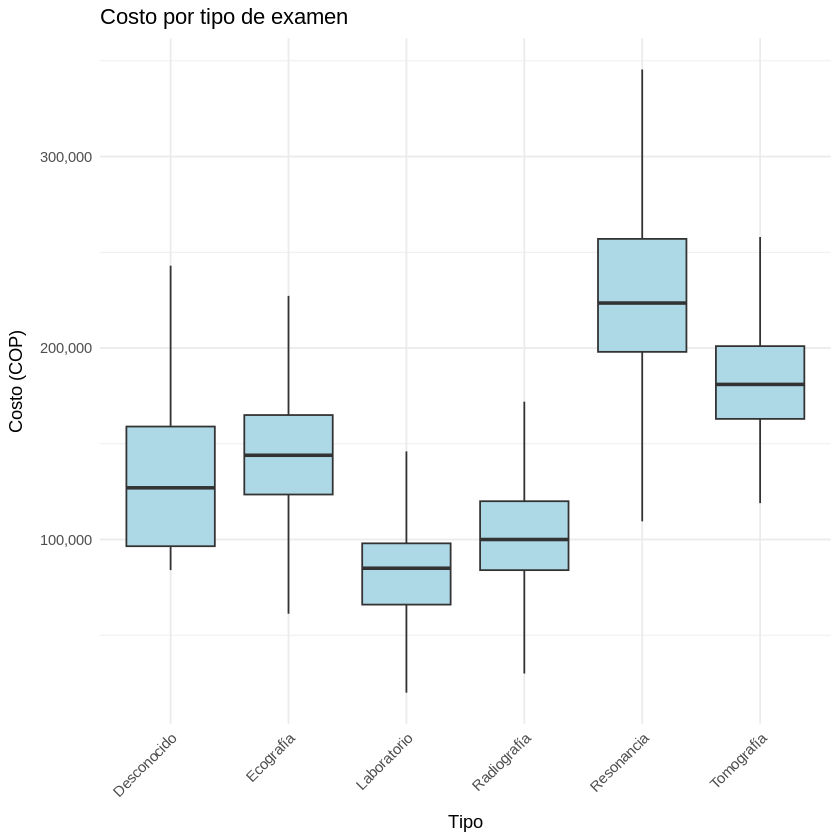

In [57]:
ggplot(datos_limpios, aes(x = tipo_examen, y = costo_examen)) +
  geom_boxplot(fill = "lightblue") +
  scale_y_continuous(labels = scales::comma) +
  labs(title = "Costo por tipo de examen", x = "Tipo", y = "Costo (COP)") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))


Las **resonancias** y **tomografías** tienen costos medianos y máximos superiores a laboratorios y radiografías. Esto confirma que el tipo de examen es un factor determinante del costo, más allá de la duración.


### 3.4.2 — Satisfacción vs reingreso a 30 días

Exploramos si la calificación que da el paciente se relaciona con que vuelva a
solicitar otro examen dentro de los 30 días siguientes.

# A tibble: 5 × 4
  calificacion_satisfaccion pacientes reingresos porcentaje
                      <dbl>     <int>      <dbl>      <dbl>
1                         1       108         29       26.9
2                         2        86         15       17.4
3                         3       141         14        9.9
4                         4        99          9        9.1
5                         5       126          6        4.8
Correlación satisfacción-reingreso: -0.219 


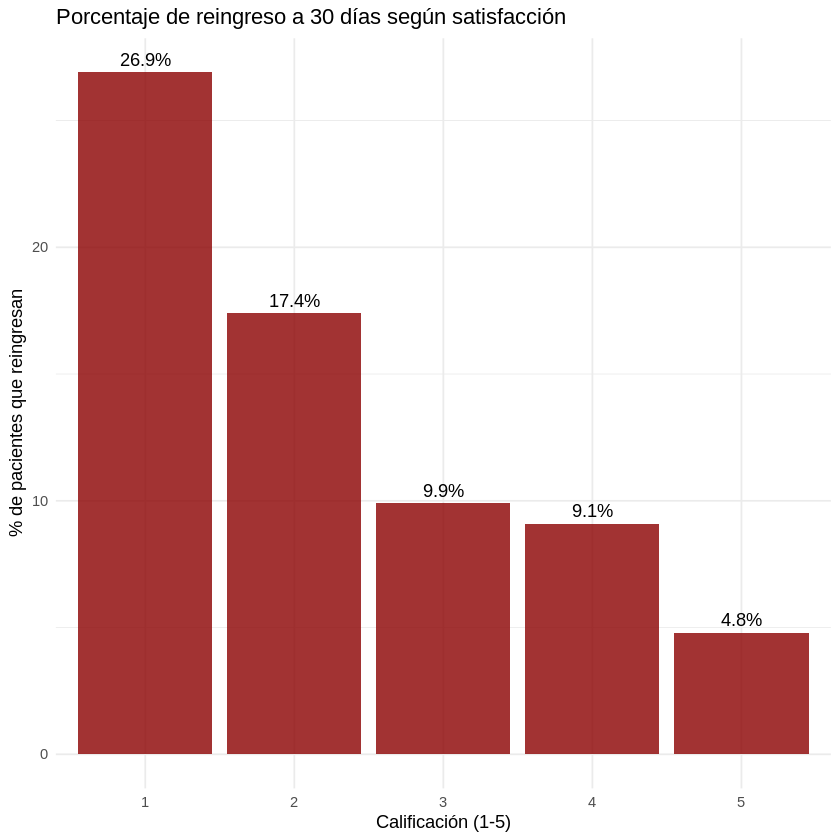

In [58]:
tabla_reingreso <- datos_limpios %>%
  group_by(calificacion_satisfaccion) %>%
  summarise(
    pacientes = n(),
    reingresos = sum(reingreso_30dias),
    porcentaje = round(100 * mean(reingreso_30dias), 1),
    .groups = "drop"
  )
print(tabla_reingreso)

cor_reingreso <- cor(datos_limpios$calificacion_satisfaccion,
                     datos_limpios$reingreso_30dias)
cat("Correlación satisfacción-reingreso:", round(cor_reingreso, 3), "\n")

ggplot(tabla_reingreso, aes(x = factor(calificacion_satisfaccion), y = porcentaje)) +
  geom_col(fill = "darkred", alpha = 0.8) +
  geom_text(aes(label = paste0(porcentaje, "%")), vjust = -0.5) +
  labs(
    title = "Porcentaje de reingreso a 30 días según satisfacción",
    x = "Calificación (1-5)", y = "% de pacientes que reingresan"
  ) +
  theme_minimal()

Existe una relación clara y decreciente: entre los pacientes que calificaron con 1,
el 26.9% volvió a solicitar un examen dentro de los 30 días; entre los que
calificaron con 5, solo el 4.8%. La correlación (-0.219) es la segunda más fuerte
del dataset después de duración-costo.

Este caso es mejor interpretarlo directamente con el ciudadano, pues el reingreso temprano puede indicar que el
primer examen no resolvió la necesidad del paciente y hubo que repetirlo o
complementarlo, lo que explicaría tanto la mala calificación como el retorno. Este caso NO se trata de una relación causal comprobada, pero sí de un patrón que la dirección
debería investigar.

### 3.4.2 — Costo por minuto según tipo de examen

Si el costo dependiera únicamente de la duración, el valor de un minuto debería ser
similar en todos los procedimientos. Verificamos si eso se cumple.

# A tibble: 6 × 5
  tipo_examen examenes duracion_mediana costo_mediano cop_por_minuto
  <chr>          <int>            <dbl>         <dbl>          <dbl>
1 Laboratorio      125             10           85000           8600
2 Radiografía      149             15          100000           6588
3 Desconocido       11             21          127000           6095
4 Ecografía        154             26.5        144000           5588
5 Tomografía        65             36          181000           5229
6 Resonancia        56             48.5        223500           4637


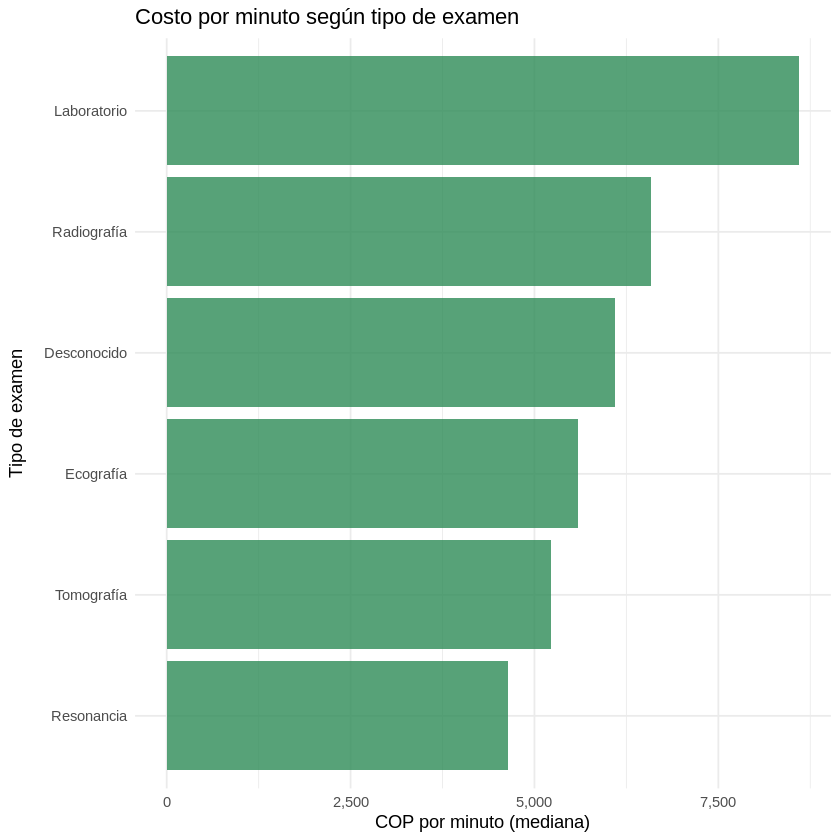

In [59]:
costo_minuto <- datos_limpios %>%
  mutate(cop_por_minuto = costo_examen / duracion_minutos) %>%
  group_by(tipo_examen) %>%
  summarise(
    examenes = n(),
    duracion_mediana = median(duracion_minutos),
    costo_mediano = median(costo_examen),
    cop_por_minuto = round(median(cop_por_minuto)),
    .groups = "drop"
  ) %>%
  arrange(desc(cop_por_minuto))

print(costo_minuto)

ggplot(costo_minuto, aes(x = reorder(tipo_examen, cop_por_minuto), y = cop_por_minuto)) +
  geom_col(fill = "seagreen", alpha = 0.8) +
  coord_flip() +
  scale_y_continuous(labels = scales::comma) +
  labs(
    title = "Costo por minuto según tipo de examen",
    x = "Tipo de examen", y = "COP por minuto (mediana)"
  ) +
  theme_minimal()

El costo del minuto no es constante entre procedimientos: un minuto de laboratorio
cuesta cerca de 8.600 COP, mientras que uno de resonancia cuesta alrededor de
4.637 COP, casi la mitad. Los exámenes largos son más costosos en total, pero
proporcionalmente más baratos por minuto.

Esto tiene una implicación directa para el modelo de regresión, porque una única recta duración -> costo tenderá a sobrestimar el costo de los exámenes largos y a subestimar el de los cortos. Entonces vemos que el equipo de modelado debería incorporar el tipo de examen como variable adicional o evaluar un término de interacción.

### 3.4.3 — Matriz de correlación

Calculamos la correlación entre todas las variables numéricas para identificar relaciones lineales y validar la fuerza de la asociación duración–costo.


                            edad dias_espera_cita duracion_minutos costo_examen
edad                       1.000            0.030           -0.020       -0.046
dias_espera_cita           0.030            1.000           -0.025       -0.014
duracion_minutos          -0.020           -0.025            1.000        0.849
costo_examen              -0.046           -0.014            0.849        1.000
calificacion_satisfaccion  0.018            0.011            0.072        0.077
reingreso_30dias          -0.060           -0.014           -0.015        0.003
                          calificacion_satisfaccion reingreso_30dias
edad                                          0.018           -0.060
dias_espera_cita                              0.011           -0.014
duracion_minutos                              0.072           -0.015
costo_examen                                  0.077            0.003
calificacion_satisfaccion                     1.000           -0.219
reingreso_30dias          

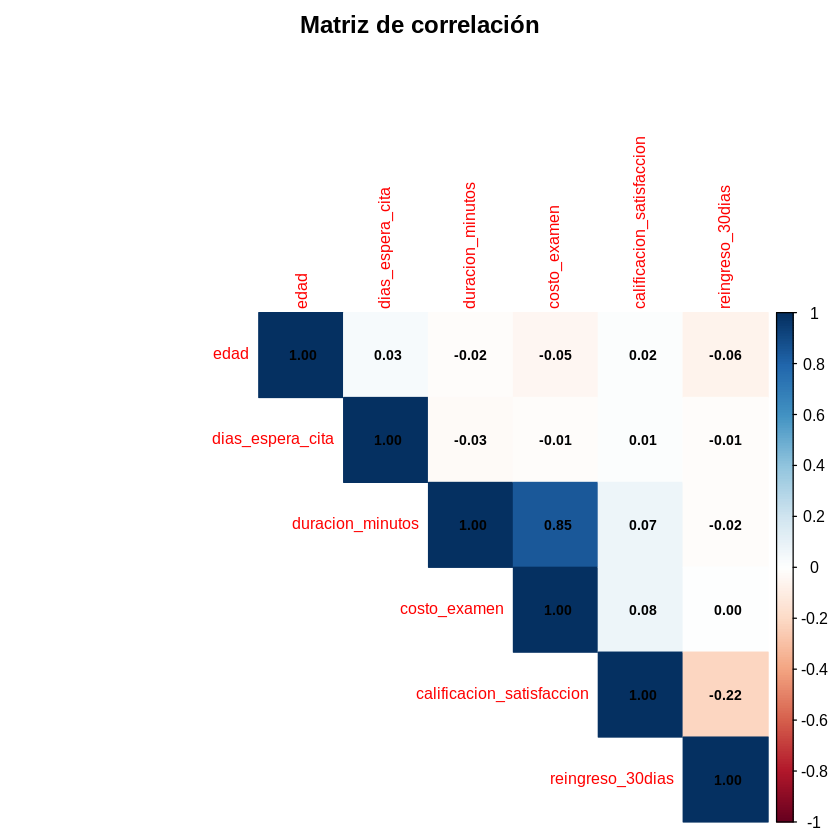

In [60]:
vars_corr <- datos_limpios %>%
  select(
    edad, dias_espera_cita, duracion_minutos,
    costo_examen, calificacion_satisfaccion, reingreso_30dias
  )

mat_corr <- cor(vars_corr, use = "complete.obs")
print(round(mat_corr, 3))

mat_spearman <- cor(vars_corr, use = "complete.obs", method = "spearman")
cat(" Matriz de Spearman ")
print(round(mat_spearman, 3))

corrplot(
  mat_corr,
  method = "color",
  type = "upper",
  addCoef.col = "black",
  number.cex = 0.7,
  tl.cex = 0.8,
  title = "Matriz de correlación",
  mar = c(0, 0, 2, 0)
)


La correlación entre **duracion_minutos** y **costo_examen** es positiva y es la más relevante para el futuro modelo. Las demás correlaciones son débiles o moderadas. Esto confirma que duración es un predictor razonable del costo, aunque no explica toda la variabilidad (hay otros factores como tipo de examen y canal).


### Hallazgos para la dirección de VitalPlus

**1. El tiempo de un examen predice bien su precio, pero cada procedimiento cobra
su minuto distinto.** A mayor duración, mayor costo: la asociación es fuerte (0.849)
y consistente. Sin embargo, el minuto no vale lo mismo en todos lados. Un minuto de
laboratorio cuesta cerca de 8.600 COP y uno de resonancia alrededor de 4.637: los
exámenes largos son más caros en total, pero proporcionalmente más económicos por
minuto. Para la clínica esto significa que llenar la agenda con procedimientos
cortos no es equivalente, en términos de ingreso por hora de equipo, a llenarla con
procedimientos largos.

**2. Hacer esperar al paciente no es lo que lo hace calificar mal.** Contrario a lo
esperado, no encontramos relación entre los días de espera y la calificación de
satisfacción (correlación de 0.011, es decir, nula). Pacientes que esperaron dos
días y pacientes que esperaron varias semanas califican prácticamente igual. Reducir
los tiempos de espera sigue siendo valioso por razones operativas, pero según estos
datos no es la palanca para mejorar la experiencia percibida.

**3. Los pacientes insatisfechos vuelven mucho más rápido.** Entre quienes
calificaron con 1, el 26.9% solicitó otro examen dentro de los 30 días siguientes;
entre quienes calificaron con 5, solo el 4.8%. El patrón es consistente en toda la
escala. Esto sugiere que una parte de los reingresos tempranos podría corresponder a
exámenes que no resolvieron la necesidad del paciente y debieron repetirse o
complementarse. Recomendamos revisar esos casos: representan un costo operativo que
hoy se registra como demanda nueva, y no como reproceso.

## 3.5 — Cierre

### ¿Los datos están listos para el modelo de regresión duración → costo?

**Sí, con reservas.** El pipeline de limpieza eliminó duplicados, unificó categorías, imputó nulos y winsorizó outliers en duración y costo. El EDA muestra una relación positiva entre ambas variables. Sin embargo, la dispersión alrededor de la tendencia y la asimetría en el costo indican que un modelo lineal simple podría no capturar toda la variabilidad.

### Advertencias al equipo de modelado

1. **Asimetría en costo:** Evaluar transformación logarítmica de `costo_examen` para estabilizar varianza.
2. **No-linealidad:** La relación duración–costo podría variar por tipo de examen; considerar variables categóricas o modelos con interacciones.
3. **Supuestos de regresión:** Verificar linealidad, homocedasticidad y normalidad de residuos antes de confiar en intervalos de predicción.
4. **Winsorización aplicada:** Los valores extremos ya fueron recortados; documentar esto al interpretar predicciones en el rango alto de costos.
